In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import GridSearchCV

from src.process import process_df
from src.helper import plot_regression_enhanced
from src.helper import remove_outliers
from src.pipe import get_ordinal_pipeline
from src.pipe import Model_pipeline




In [29]:
df = pd.read_csv('data/apartments_raw_data.csv')
df=process_df(df)

In [30]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

known_data = df[df["location_type"].notna()]
missing_data = df[df["location_type"].isna()]

if not missing_data.empty:
    knn = KNeighborsClassifier(n_neighbors=3)

    knn.fit(known_data[["latitude", "longitude"]], known_data["location_type"])
    
    predictions = knn.predict(missing_data[["latitude", "longitude"]])
    df.loc[df["location_type"].isna(), "location_type"] = predictions

print(f"Unique values after filling: {df['location_type'].unique()}")

Unique values after filling: ['Klidná část obce', 'Centrum obce', 'Okraj obce', 'Sídliště', 'Rušná část obce', 'Polosamota']
Categories (6, object): ['Centrum obce', 'Klidná část obce', 'Okraj obce', 'Polosamota', 'Rušná část obce', 'Sídliště']


In [31]:
df_scoped = remove_outliers(df)
print(f"Original shape: {df.shape} | New shape: {df_scoped.shape}")

Original shape: (11269, 23) | New shape: (11246, 23)


In [32]:
X = df_scoped.drop(['price_total'], axis=1)
y = np.log1p(df_scoped['price_total']) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.26, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [33]:
num_features = [
    "latitude",
    "longitude",
    "usable_area_m2",
    "total_area_m2",
    "loggia_area_m2",
    "cellar_area_m2",
    "floor_number",
    "total_floors",
]

bool_features = [
    "has_elevator",
    "has_garage",
    "has_cellar",
    "has_terrace",
    "has_loggia",
]


In [34]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_pipeline = Model_pipeline(
    num_features=num_features,
    bool_features=bool_features,
    model_type="tree",
    model=DecisionTreeRegressor(random_state=42)
)
decision_tree_pipeline.fit(X_train, y_train)
decision_tree_pipeline.get_score(X_val, y_val,r2_score,scale_back=True)

0.7842915523135683

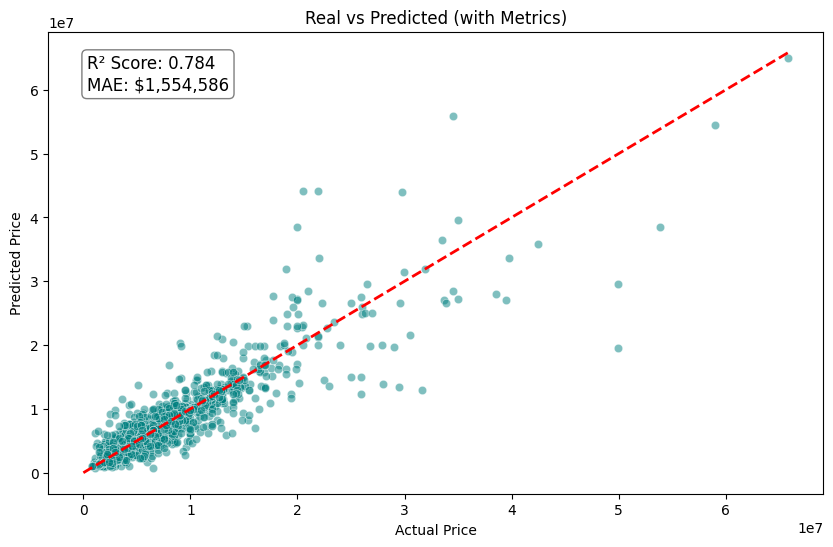

In [35]:
plot_regression_enhanced(y_val, decision_tree_pipeline.predict(X_val))


In [36]:
from xgboost import XGBRegressor
xgb_pipeline = Model_pipeline(
    num_features=num_features,
    bool_features=bool_features,
    model_type="tree",
    model=XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        reg_alpha=0.1,
        random_state=42,
        max_depth=7,
        n_jobs=-1,
        )
)
xgb_pipeline.fit(X_train, y_train)
xgb_pipeline.get_score(X_val, y_val,r2_score,scale_back=True)


0.8934262285858867

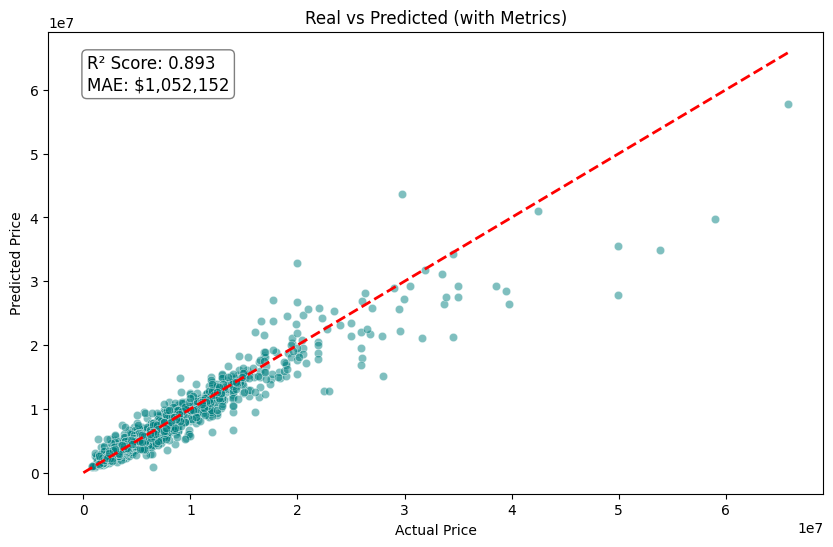

In [37]:
plot_regression_enhanced(y_val, xgb_pipeline.predict(X_val))


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
rf_pipeline = Pipeline([
    ('preprocessor', get_ordinal_pipeline(num_features,bool_features,'tree')), 
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 15, 20, None],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', None] 
}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring='r2',
    cv=3,           
    n_jobs=-1,      
)

grid_search_rf.fit(X_train, y_train)


best_model_pipeline = grid_search_rf.best_estimator_
rf_pipeline=Model_pipeline(
    num_features=num_features,
    bool_features=bool_features,
    model_type="tree",
    model=best_model_pipeline.named_steps['regressor'],
)
rf_pipeline.fit(X_train, y_train)
rf_pipeline.get_score(X_val, y_val,r2_score,scale_back=True)


0.8585547625033031

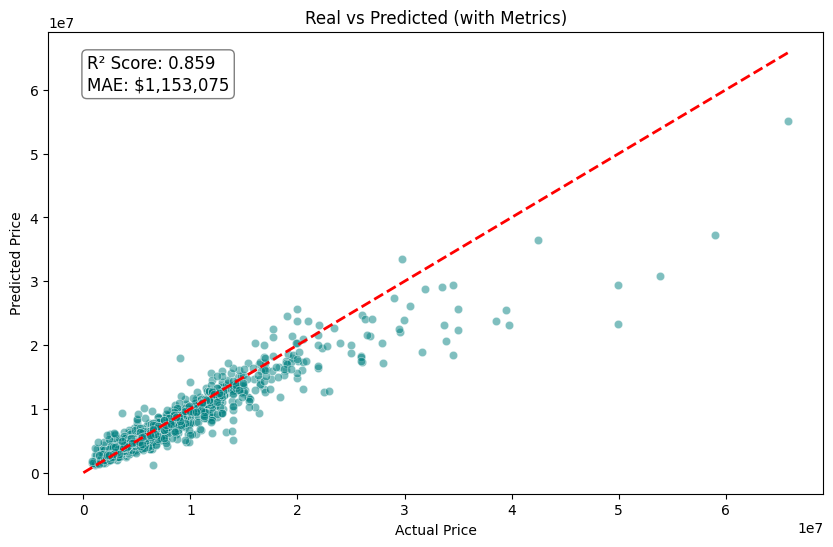

In [39]:
plot_regression_enhanced(y_val, rf_pipeline.predict(X_val))
